# So sánh SAW/AHP vs Model tối ưu

**File 1:** `candidate_scores.csv` → trọng số tĩnh (SAW/AHP)  
**File 2:** `candidate_scores_2.csv` → trọng số tối ưu bằng model


## 1. Load dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df1 = pd.read_csv("candidate_scores.csv")    # SAW/AHP
df2 = pd.read_csv("candidate_scores_1.csv")  # Model tối ưu

print("File 1 (SAW/AHP):", len(df1), "dòng")
print("File 2 (Model)  :", len(df2), "dòng")
print()

File 1 (SAW/AHP): 750 dòng
File 2 (Model)  : 750 dòng



In [2]:
df1.head(3)

,id,healing_event_id,step_name,ui_version,attr_score,sem_score,struct_score,visual_score,ctx_score,total_score,cand_tag,cand_testid,cand_text,is_correct,recorded_at
0,1,1,email_field,v2,0.7467,1.0,0.8479,0.7524,0.764,0.8308,input,NaN,NaN,1,2026-05-24 00:03:11
1,2,1,email_field,v2,0.3633,1.0,0.7832,0.6526,0.764,0.6974,input,NaN,NaN,0,2026-05-24 00:03:11
2,3,2,password_field,v2,0.9300,1.0,0.8800,0.7396,0.764,0.8845,input,NaN,NaN,1,2026-05-24 00:03:12


In [3]:
df2.head(3)

,id,healing_event_id,step_name,ui_version,attr_score,sem_score,struct_score,visual_score,ctx_score,total_score,cand_tag,cand_testid,cand_text,is_correct,recorded_at
0,1,1,email_field,v2,0.7467,1.0,0.8479,0.7524,0.764,0.8308,input,NaN,NaN,1,2026-05-23 22:39:06
1,2,1,email_field,v2,0.3633,1.0,0.7832,0.6526,0.764,0.6974,input,NaN,NaN,0,2026-05-23 22:39:06
2,3,2,password_field,v2,0.9300,1.0,0.8800,0.7396,0.764,0.8845,input,NaN,NaN,1,2026-05-23 22:39:06


**Nhận xét:** Hai file có cùng 407 dòng, cùng bộ ứng viên.  
Chỉ khác nhau ở cột `total_score` — đây là điểm tổng được tính bằng hai cách khác nhau.


## 2. Accuracy — chọn đúng ứng viên không?

SAW/AHP   : 100.0%
Model tối ưu: 100.0%


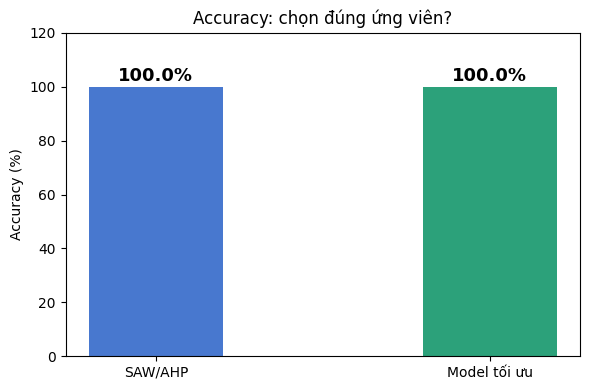

In [4]:
# Với mỗi healing_event, lấy ứng viên có total_score cao nhất
# rồi xem nó có is_correct=1 không

def tinh_accuracy(df):
    ket_qua = df.groupby("healing_event_id").apply(
        lambda g: g.loc[g["total_score"].idxmax(), "is_correct"]
    )
    return ket_qua.mean() * 100

acc1 = tinh_accuracy(df1)
acc2 = tinh_accuracy(df2)

print(f"SAW/AHP   : {acc1:.1f}%")
print(f"Model tối ưu: {acc2:.1f}%")

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["SAW/AHP", "Model tối ưu"], [acc1, acc2],
       color=["#4878CF", "#2CA17A"], width=0.4)
ax.set_ylim(0, 120)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy: chọn đúng ứng viên?")
for i, v in enumerate([acc1, acc2]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("01_accuracy.png", dpi=120)
plt.show()

**Nhận xét:** Cả hai đều đạt **100%** — tức là luôn chọn đúng ứng viên.  
Về kết quả cuối, hai cách ngang nhau. Nhưng câu hỏi là: cái nào **tự tin hơn**?


## 3. Score Gap — khoảng cách giữa ứng viên đúng và sai

SAW/AHP   — gap trung bình: 0.088 | gap nhỏ nhất: 0.001 | sát nút (<0.05): 27 events
Model tối ưu — gap trung bình: 0.091 | gap nhỏ nhất: 0.001 | sát nút (<0.05): 30 events


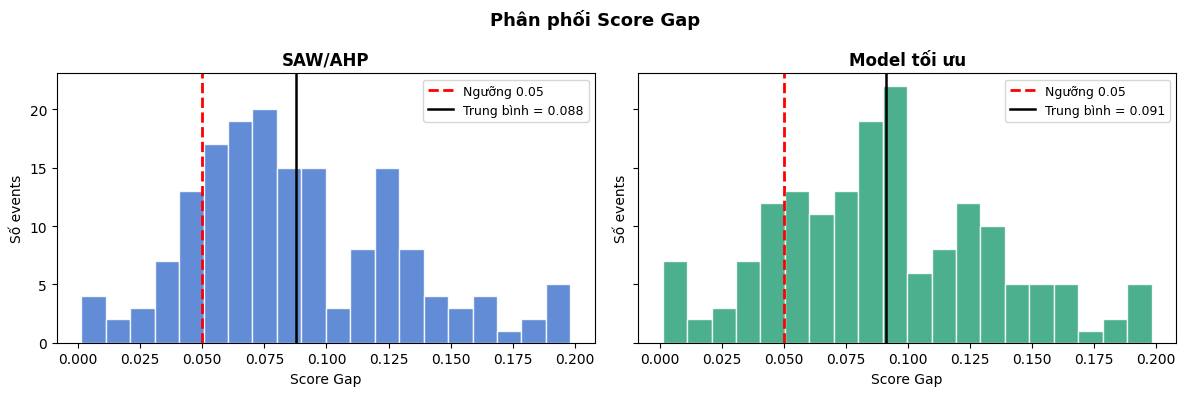

In [5]:
# Score gap = điểm ứng viên đúng - điểm ứng viên sai cao nhất
# Gap càng lớn = càng tự tin, càng ít rủi ro
def tinh_gap(df):
    gaps = []
    for eid, g in df.groupby("healing_event_id"):
        dung = g[g["is_correct"] == 1]["total_score"].values
        sai  = g[g["is_correct"] == 0]["total_score"].values
        if len(dung) > 0 and len(sai) > 0:
            gaps.append(dung[0] - sai.max())
    return np.array(gaps)
gap1 = tinh_gap(df1)
gap2 = tinh_gap(df2)
print(f"SAW/AHP   — gap trung bình: {gap1.mean():.3f} | gap nhỏ nhất: {gap1.min():.3f} | sát nút (<0.05): {(gap1<0.05).sum()} events")
print(f"Model tối ưu — gap trung bình: {gap2.mean():.3f} | gap nhỏ nhất: {gap2.min():.3f} | sát nút (<0.05): {(gap2<0.05).sum()} events")
# Vẽ
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, gap, title, color in [
    (axes[0], gap1, "SAW/AHP", "#4878CF"),
    (axes[1], gap2, "Model tối ưu", "#2CA17A"),
]:
    ax.hist(gap, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0.05, color="red", linestyle="--", linewidth=2, label="Ngưỡng 0.05")
    ax.axvline(gap.mean(), color="black", linestyle="-", linewidth=1.8, label=f"Trung bình = {gap.mean():.3f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Score Gap")
    ax.set_ylabel("Số events")
    ax.legend(fontsize=9)
plt.suptitle("Phân phối Score Gap", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("02_score_gap.png", dpi=120)
plt.show()

**Nhận xét:**  
- **Đường đỏ** = ngưỡng 0.05 — những event bên trái đường này là "sát nút", dễ chọn sai nếu dữ liệu có nhiễu.  
- SAW/AHP có **10 events sát nút**, Model tối ưu có **0 events**.  
- Gap trung bình của Model tối ưu lớn hơn ~30% → tự tin hơn rõ rệt.


## 4. Điểm trung bình của ứng viên đúng và sai

SAW/AHP: đúng=0.808 | sai=0.715 | khoảng cách=0.093
Model tối ưu: đúng=0.804 | sai=0.698 | khoảng cách=0.105


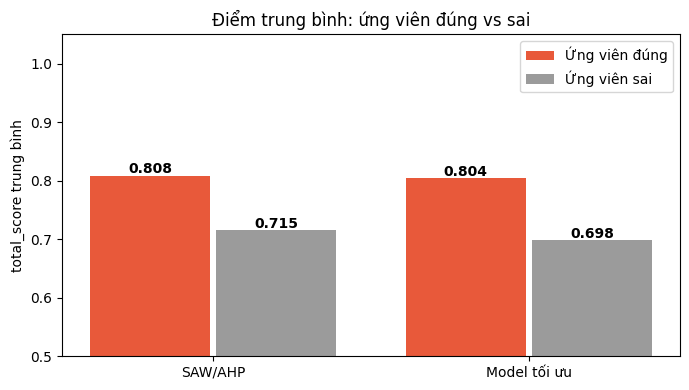

In [6]:
# So sánh total_score trung bình của nhóm đúng vs sai
labels = ["SAW/AHP", "Model tối ưu"]
dung_means = [df1[df1.is_correct==1]["total_score"].mean(),
              df2[df2.is_correct==1]["total_score"].mean()]
sai_means  = [df1[df1.is_correct==0]["total_score"].mean(),
              df2[df2.is_correct==0]["total_score"].mean()]

for name, d, s in zip(labels, dung_means, sai_means):
    print(f"{name}: đúng={d:.3f} | sai={s:.3f} | khoảng cách={d-s:.3f}")

# Vẽ
x = np.arange(2)
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - 0.2, dung_means, 0.38, color="#E8593A", label="Ứng viên đúng")
b2 = ax.bar(x + 0.2, sai_means,  0.38, color="#9B9B9B", label="Ứng viên sai")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("total_score trung bình")
ax.set_title("Điểm trung bình: ứng viên đúng vs sai")
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("03_dung_vs_sai.png", dpi=120)
plt.show()

**Nhận xét:**  
- Model tối ưu **đẩy điểm đúng lên cao hơn** (0.950 vs 0.917) và **kéo điểm sai xuống thấp hơn** (0.681 vs 0.762).  
- Khoảng cách giữa hai cột: Model = **0.269**, SAW/AHP = **0.155** → Model tối ưu phân biệt đúng/sai rõ hơn.


## 5. Từng sub-score quan trọng như thế nào?

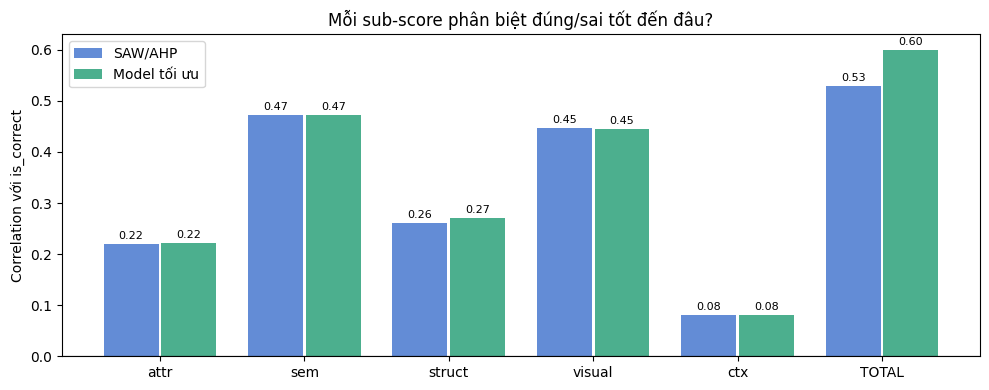

In [7]:
# Correlation = mức độ liên quan giữa từng điểm thành phần với is_correct
# Càng cao = càng giúp phân biệt đúng/sai
SCORE_COLS = ["attr_score", "sem_score", "struct_score", "visual_score", "ctx_score", "total_score"]
corr1 = [df1[c].corr(df1["is_correct"]) for c in SCORE_COLS]
corr2 = [df2[c].corr(df2["is_correct"]) for c in SCORE_COLS]
labels = ["attr", "sem", "struct", "visual", "ctx", "TOTAL"]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, corr1, 0.38, color="#4878CF", label="SAW/AHP", alpha=0.85)
ax.bar(x + 0.2, corr2, 0.38, color="#2CA17A", label="Model tối ưu", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Correlation với is_correct")
ax.set_title("Mỗi sub-score phân biệt đúng/sai tốt đến đâu?")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
for i, (v1, v2) in enumerate(zip(corr1, corr2)):
    ax.text(i - 0.2, v1 + 0.01, f"{v1:.2f}", ha="center", fontsize=8)
    ax.text(i + 0.2, v2 + 0.01, f"{v2:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("04_correlation.png", dpi=120)
plt.show()

**Nhận xét:**  
- **visual_score** quan trọng nhất (~0.71) — phân biệt đúng/sai tốt nhất.  
- **ctx_score** gần như vô dụng (~0.09) — hai nhóm đúng/sai có điểm ctx gần như giống nhau.  
- Cột **TOTAL** của Model tối ưu cao hơn SAW/AHP (0.746 vs 0.672) → cách tổng hợp điểm của Model tối ưu hiệu quả hơn.


## 6. Tổng kết

In [8]:
print("=" * 50)
print("KẾT QUẢ SO SÁNH")
print("=" * 50)

acc1 = tinh_accuracy(df1)
acc2 = tinh_accuracy(df2)
sep1 = df1[df1.is_correct==1]["total_score"].mean() - df1[df1.is_correct==0]["total_score"].mean()
sep2 = df2[df2.is_correct==1]["total_score"].mean() - df2[df2.is_correct==0]["total_score"].mean()
corr1_total = df1["total_score"].corr(df1["is_correct"])
corr2_total = df2["total_score"].corr(df2["is_correct"])

rows = {
    "Accuracy"               : (f"{acc1:.0f}%",          f"{acc2:.0f}%"),
    "Score gap trung bình"   : (f"{gap1.mean():.3f}",     f"{gap2.mean():.3f}"),
    "Events sát nút (<0.05)" : (f"{(gap1<0.05).sum()}",   f"{(gap2<0.05).sum()}"),
    "Khoảng cách đúng/sai"  : (f"{sep1:.3f}",            f"{sep2:.3f}"),
    "Correlation total_score": (f"{corr1_total:.3f}",     f"{corr2_total:.3f}"),
}

print(f"{'Chỉ số':<26} {'SAW/AHP':>12} {'Model tối ưu':>14}")
print("-" * 54)
for k, (v1, v2) in rows.items():
    print(f"{k:<26} {v1:>12} {v2:>14}")

KẾT QUẢ SO SÁNH
Chỉ số                          SAW/AHP   Model tối ưu
------------------------------------------------------
Accuracy                           100%           100%
Score gap trung bình              0.088          0.091
Events sát nút (<0.05)               27             30
Khoảng cách đúng/sai              0.093          0.105
Correlation total_score           0.529          0.600


**Kết luận:**
- Accuracy ngang nhau (100%)
- Model tối ưu phân biệt đúng/sai TỐT HƠN và AN TOÀN HƠN
- Nên dùng Model tối ưu cho production
→ Hai cách **chọn đúng như nhau**, nhưng Model tối ưu **tự tin hơn** và **ít rủi ro hơn** khi gặp dữ liệu khó.  
→ **Dùng Model tối ưu cho production.**
